In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
X = []
Y = []

img_size = 224

# Kaggle dataset path
base_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

for cls, label in classes.items():

    path = os.path.join(base_path, cls)

    for filename in os.listdir(path):

        img_path = os.path.join(path, filename)

        # Read image
        img = cv2.imread(img_path)

        # Skip corrupted images
        if img is None:
            continue

        # Resize image
        img = cv2.resize(img, (img_size, img_size))

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Normalize image
        img = img.astype('float32') / 255.0

        # Flatten image for PCA
        img = img.flatten()

        # Store image and label
        X.append(img)
        Y.append(label)

# Convert into numpy arrays
X = np.array(X)
Y = np.array(Y)

print("X shape :", X.shape)
print("Y shape :", Y.shape)

X shape : (2870, 150528)
Y shape : (2870,)


In [3]:
tumor_names = {
    0: "No Tumor",
    1: "Pituitary Tumor",
    2: "Glioma Tumor",
    3: "Meningioma Tumor"
}

unique, counts = np.unique(Y, return_counts=True)

tumor_count_df = pd.DataFrame({
    "Tumor Type": [tumor_names[i] for i in unique],
    "Count": counts
})

tumor_count_df

,Tumor Type,Count
0,No Tumor,395
1,Pituitary Tumor,827
2,Glioma Tumor,826
3,Meningioma Tumor,822


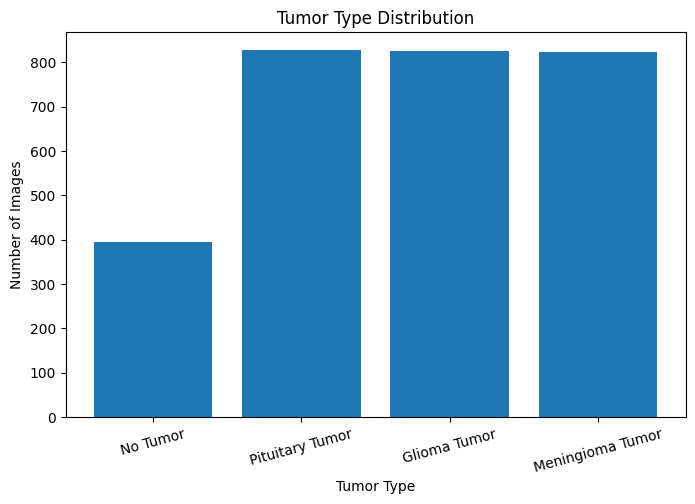

In [4]:
plt.figure(figsize=(8,5))

plt.bar(
    tumor_count_df["Tumor Type"],
    tumor_count_df["Count"]
)

plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")
plt.title("Tumor Type Distribution")

plt.xticks(rotation=15)

plt.show()

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print("Training Shape :", X_train_full.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (2296, 150528)
Testing Shape  : (574, 150528)


In [6]:
pca = PCA(n_components=100)

X_train_full_pca = pca.fit_transform(X_train_full)

X_test_pca = pca.transform(X_test)

print("PCA Training Shape :", X_train_full_pca.shape)
print("PCA Testing Shape  :", X_test_pca.shape)

PCA Training Shape : (2296, 100)
PCA Testing Shape  : (574, 100)


In [7]:
def calculate_metrics(y_true, y_pred):

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # F1 Score
    f1 = f1_score(y_true, y_pred, average='weighted')

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    sensitivities = []
    specificities = []

    for i in range(len(cm)):

        TP = cm[i, i]

        FN = np.sum(cm[i, :]) - TP

        FP = np.sum(cm[:, i]) - TP

        TN = np.sum(cm) - (TP + FP + FN)

        sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0

        specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

        sensitivities.append(sensitivity)

        specificities.append(specificity)

    avg_sensitivity = np.mean(sensitivities)

    avg_specificity = np.mean(specificities)

    return accuracy, f1, avg_sensitivity, avg_specificity

In [8]:
svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train_full_pca, y_train_full)

y_pred_rbf = svm_rbf.predict(X_test_pca)

acc_rbf, f1_rbf, sens_rbf, spec_rbf = calculate_metrics(
    y_test,
    y_pred_rbf
)

print("===== RBF Kernel Results =====")

print("Accuracy    :", acc_rbf)
print("F1 Score    :", f1_rbf)
print("Sensitivity :", sens_rbf)
print("Specificity :", spec_rbf)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rbf))

===== RBF Kernel Results =====
Accuracy    : 0.837979094076655
F1 Score    : 0.8366296099535646
Sensitivity : 0.8258156203922598
Specificity : 0.9441350004023424

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.75      0.80        79
           1       0.89      0.96      0.92       166
           2       0.84      0.83      0.83       165
           3       0.77      0.77      0.77       164

    accuracy                           0.84       574
   macro avg       0.84      0.83      0.83       574
weighted avg       0.84      0.84      0.84       574



In [9]:
svm_linear = SVC(kernel='linear')

svm_linear.fit(X_train_full_pca, y_train_full)

y_pred_linear = svm_linear.predict(X_test_pca)

acc_linear, f1_linear, sens_linear, spec_linear = calculate_metrics(
    y_test,
    y_pred_linear
)

print("===== Linear Kernel Results =====")

print("Accuracy    :", acc_linear)
print("F1 Score    :", f1_linear)
print("Sensitivity :", sens_linear)
print("Specificity :", spec_linear)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_linear))

===== Linear Kernel Results =====
Accuracy    : 0.705574912891986
F1 Score    : 0.7022233560408923
Sensitivity : 0.6841247966408844
Specificity : 0.8997157382370994

Classification Report

              precision    recall  f1-score   support

           0       0.61      0.54      0.57        79
           1       0.81      0.90      0.85       166
           2       0.74      0.67      0.70       165
           3       0.61      0.62      0.61       164

    accuracy                           0.71       574
   macro avg       0.69      0.68      0.69       574
weighted avg       0.70      0.71      0.70       574



In [10]:
training_percentages = [0.2, 0.4, 0.6, 0.8]

rbf_accuracies = []
linear_accuracies = []

results = []

for train_size in training_percentages:

    # Use only part of training data
    X_train_partial, _, y_train_partial, _ = train_test_split(
        X_train_full_pca,
        y_train_full,
        train_size=train_size,
        random_state=42,
        stratify=y_train_full
    )

    # =========================================
    # RBF Kernel
    # =========================================
    svm_rbf = SVC(kernel='rbf')

    svm_rbf.fit(X_train_partial, y_train_partial)

    y_pred_rbf = svm_rbf.predict(X_test_pca)

    acc_rbf, f1_rbf, sens_rbf, spec_rbf = calculate_metrics(
        y_test,
        y_pred_rbf
    )

    rbf_accuracies.append(acc_rbf)

    results.append([
        f"{int(train_size*100)}%",
        "RBF",
        acc_rbf,
        f1_rbf,
        sens_rbf,
        spec_rbf
    ])

    # =========================================
    # Linear Kernel
    # =========================================
    svm_linear = SVC(kernel='linear')

    svm_linear.fit(X_train_partial, y_train_partial)

    y_pred_linear = svm_linear.predict(X_test_pca)

    acc_linear, f1_linear, sens_linear, spec_linear = calculate_metrics(
        y_test,
        y_pred_linear
    )

    linear_accuracies.append(acc_linear)

    results.append([
        f"{int(train_size*100)}%",
        "Linear",
        acc_linear,
        f1_linear,
        sens_linear,
        spec_linear
    ])

    print(f"Completed for {int(train_size*100)}% Training Data")

Completed for 20% Training Data
Completed for 40% Training Data
Completed for 60% Training Data
Completed for 80% Training Data


In [11]:
# ============================================================
# CELL 12 — Results Table
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Training Data",
        "Kernel",
        "Accuracy",
        "F1-Score",
        "Sensitivity",
        "Specificity"
    ]
)

results_df

,Training Data,Kernel,Accuracy,F1-Score,Sensitivity,Specificity
0,20%,RBF,0.747387,0.742461,0.727041,0.913310
1,20%,Linear,0.655052,0.650724,0.645059,0.882396
2,40%,RBF,0.778746,0.776030,0.762635,0.924217
3,40%,Linear,0.655052,0.655713,0.643519,0.884013
4,60%,RBF,0.803136,0.801075,0.787238,0.932344
5,60%,Linear,0.700348,0.698076,0.691152,0.898076
6,80%,RBF,0.815331,0.813341,0.797853,0.936510
7,80%,Linear,0.702091,0.699805,0.687683,0.898709


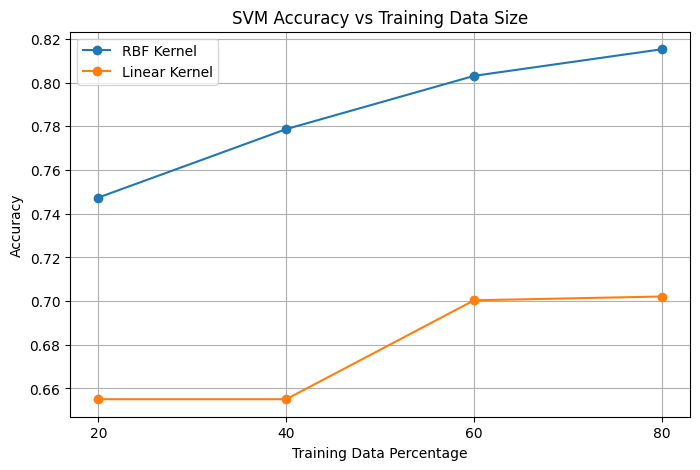

In [12]:
training_labels = [20, 40, 60, 80]

plt.figure(figsize=(8,5))

plt.plot(
    training_labels,
    rbf_accuracies,
    marker='o',
    label='RBF Kernel'
)

plt.plot(
    training_labels,
    linear_accuracies,
    marker='o',
    label='Linear Kernel'
)

plt.xlabel("Training Data Percentage")
plt.ylabel("Accuracy")

plt.title("SVM Accuracy vs Training Data Size")

plt.xticks(training_labels)

plt.legend()

plt.grid(True)

plt.show()

In [13]:

print("RBF Kernel Accuracies")
for size, acc in zip([20,40,60,80], rbf_accuracies):
    print(f"{size}% Training Data : {acc:.4f}")

print("\nLinear Kernel Accuracies")
for size, acc in zip([20,40,60,80], linear_accuracies):
    print(f"{size}% Training Data : {acc:.4f}")

RBF Kernel Accuracies
20% Training Data : 0.7474
40% Training Data : 0.7787
60% Training Data : 0.8031
80% Training Data : 0.8153

Linear Kernel Accuracies
20% Training Data : 0.6551
40% Training Data : 0.6551
60% Training Data : 0.7003
80% Training Data : 0.7021
